In [1]:
import tensorflow as tf
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dense
from tensorflow.keras.models import Sequential
import random
import numpy as np

In [2]:
seed = 42
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

In [20]:
##Load mnist dataset
mnist = tf.keras.datasets.mnist
(x_train,y_train),(x_test,y_test) = mnist.load_data()

In [21]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


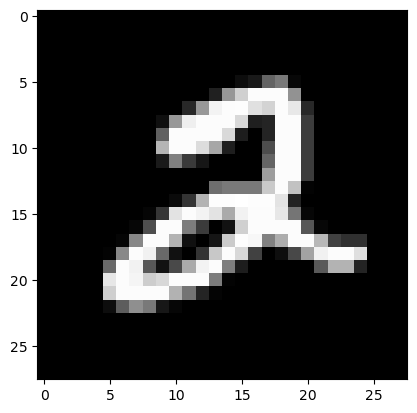

Letter is  2


In [22]:
from matplotlib import pyplot as plt
plt.imshow(x_train[5],cmap='gray')
plt.show()
print("Letter is ",y_train[5])

In [23]:
x_train = x_train.reshape(-1,28,28,1)
x_test = x_test.reshape(-1,28,28,1)
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(60000, 28, 28, 1)
(60000,)
(10000, 28, 28, 1)
(10000,)


In [24]:
print(y_train)

[5 0 4 ... 5 6 8]


In [25]:

y_train = tf.keras.utils.to_categorical(y_train)
y_test = tf.keras.utils.to_categorical(y_test)

In [27]:
print(y_train)

[[0. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 1. 0.]]


In [30]:
cnnModel = Sequential()

cnnModel.add(Conv2D(10, (3,3), activation="relu", input_shape=(28,28,1)))

cnnModel.add(Conv2D(10, (3,3), activation="relu", input_shape=(28,28,1)))
cnnModel.add(MaxPooling2D((2,2)))
cnnModel.add(Conv2D(64, (3,3), activation="relu"))
cnnModel.add(MaxPooling2D((2,2)))
cnnModel.add(Conv2D(64, (3,3), activation="relu"))
cnnModel.add(Flatten())
cnnModel.add(Dense(64, activation="relu"))
cnnModel.add(Dense(32, activation="relu"))
cnnModel.add(Dense(10, activation="softmax"))

cnnModel.summary()


Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 26, 26, 10)        100       
                                                                 
 conv2d_1 (Conv2D)           (None, 24, 24, 10)        910       
                                                                 
 max_pooling2d (MaxPooling2  (None, 12, 12, 10)        0         
 D)                                                              
                                                                 
 conv2d_2 (Conv2D)           (None, 10, 10, 64)        5824      
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 5, 5, 64)          0         
 g2D)                                                            
                                                                 
 conv2d_3 (Conv2D)           (None, 3, 3, 64)        

In [31]:
cnnModel.compile(optimizer="Adam", loss="categorical_crossentropy",metrics=["accuracy"])

In [ ]:
history = cnnModel.fit(x_train, y_train, epochs=20, batch_size=32,  validation_data=(x_test,y_test))

Epoch 1/20


1875/1875 [==============================] - 18s 8ms/step - loss: 0.2520 - accuracy: 0.9346 - val_loss: 0.0579 - val_accuracy: 0.9821
Epoch 2/20
1875/1875 [==============================] - 18s 9ms/step - loss: 0.0619 - accuracy: 0.9814 - val_loss: 0.1202 - val_accuracy: 0.9625
Epoch 3/20
1875/1875 [==============================] - 18s 10ms/step - loss: 0.0495 - accuracy: 0.9852 - val_loss: 0.0386 - val_accuracy: 0.9872
Epoch 4/20
1875/1875 [==============================] - 16s 9ms/step - loss: 0.0406 - accuracy: 0.9878 - val_loss: 0.0464 - val_accuracy: 0.9862
Epoch 5/20
1875/1875 [==============================] - 16s 9ms/step - loss: 0.0358 - accuracy: 0.9893 - val_loss: 0.0590 - val_accuracy: 0.9844
Epoch 6/20
1875/1875 [==============================] - 17s 9ms/step - loss: 0.0291 - accuracy: 0.9914 - val_loss: 0.0385 - val_accuracy: 0.9894
Epoch 7/20
1808/1875 [===========================>..] - ETA: 0s - loss: 0.0280 - accuracy: 0.9920

In [ ]:
testLoss, testAccuracy = cnnModel.evaluate(x_test, y_test)

In [ ]:
y_pred = cnnModel.predict(x_test)

In [ ]:
print(y_pred)

In [ ]:
tf.math.confusion_matrix(np.argmax(y_test, axis=1),y_pred)

In [ ]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

In [ ]:
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label = 'val_loss')
plt.xlabel('Epoch')
plt.ylabel('loss')
plt.legend(loc='lower right')